# Financial Econometrics Final Project

*Shivani Samlal & Evan Klos - Group 7*

# Data Preparation

In [3]:
### Block 0 - Mount Google Drive ###

# Mount Google Drive
import os

gdrp = '/content/gdrive/'
from google.colab import drive
try:
  drive.mount(gdrp)
except:
  drive.mount(gdrp, force_remount=True)
  print('drive mounted')

rootpath = gdrp + 'My Drive/Colab Notebooks/groupproject'
os.chdir(rootpath)

Mounted at /content/gdrive/


In [4]:
### Block 1 - Imports and Constants ###

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt

import warnings
warnings.filterwarnings('ignore')

# Date boundaries
data_start = '2018-07-01'
data_end = '2022-06-01'   # last observed date in loans_head.csv
forecast_start = '2022-07-01'
forecast_end = '2023-06-01'  # 12 months ahead

In [5]:
### Block 2 - Load loans_head data and aggregate ###

# Loading loans_head data and manipulating
df = pd.read_csv('loans_head.csv', parse_dates=True, index_col=0)

# Ensure monthly frequency and clean numeric fields
df = df.asfreq('MS').sort_index()
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(0, inplace=True)

# Aggregate to Total Balance series
total = pd.DataFrame(df.sum(axis=1), columns=['Total_Balance']).asfreq('MS')
total = total.loc[data_start:data_end]

print("Loaded loans data. Time index from", total.index.min(), "to", total.index.max())
print("Number of accounts (columns):", df.shape[1])

display(total.head())

Loaded loans data. Time index from 2018-07-01 00:00:00 to 2022-06-01 00:00:00
Number of accounts (columns): 1058


,Total_Balance
observation_date,
2018-07-01,22662913.00
2018-08-01,25544354.25
2018-09-01,26656673.31
2018-10-01,29930314.81
2018-11-01,33127820.58


# Exploratory Data Analysis (EDA)

In [6]:
### Block 3a - Summary Statistics ###

print("--- Summary Statistics: Total Balance ---")
display(total['Total_Balance'].describe().apply("{0:,.2f}".format))

print("\n--- Summary Statistics: Across 1,058 Accounts ---")
display(df.describe().loc[['mean', 'std', 'min', 'max']])


--- Summary Statistics: Total Balance ---


,Total_Balance
count,48.00
mean,"66,615,042.81"
std,"34,677,591.31"
min,"22,662,913.00"
25%,"36,191,857.22"
50%,"58,953,417.48"
75%,"92,795,282.26"
max,"171,095,437.01"



--- Summary Statistics: Across 1,058 Accounts ---


,0,1,2,3,4,5,6,7,8,9,...,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057
mean,1466.910833,7269.517292,2861.003542,18187.396458,1718.899167,6220.648542,13527.096458,8735.523125,12243.143125,15473.326042,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,3166.086925,18357.089794,7689.286289,83539.161370,3351.459760,17326.723644,18020.365795,19795.795527,18263.943046,31917.135879,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1633.410000,0.000000,913.250000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,11338.180000,72225.450000,48709.290000,572362.350000,11338.180000,72225.450000,89495.120000,68274.510000,89495.120000,154046.730000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


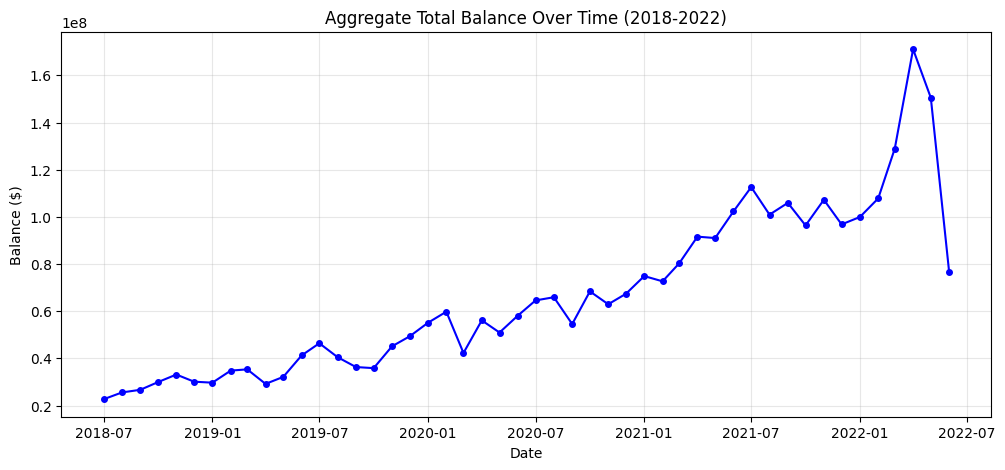

In [7]:
### Block 3b - Time Series Plot ###

plt.figure(figsize=(12, 5))
plt.plot(total.index, total['Total_Balance'], marker='o', markersize=4, linestyle='-', linewidth=1.5, color='blue')
plt.title("Aggregate Total Balance Over Time (2018-2022)")
plt.xlabel("Date")
plt.ylabel("Balance ($)")
plt.grid(True, alpha=0.3)
plt.show()

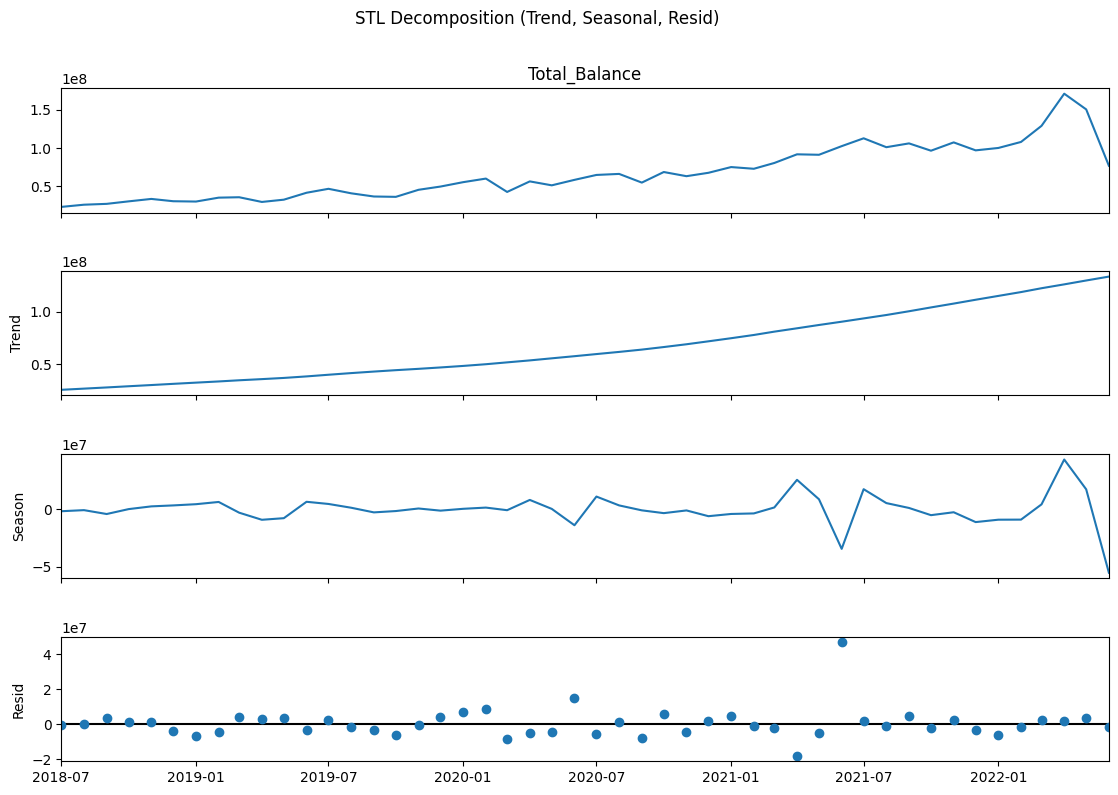

In [8]:
### Block 3c - STL Decomposition ###

# Decomposes into Trend, Seasonality, and Residuals
# seasonal=13 ensures a stable seasonal window (must be odd)
stl = STL(total['Total_Balance'], period=12, seasonal=13, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle('STL Decomposition (Trend, Seasonal, Resid)', y=1.02)
plt.show()

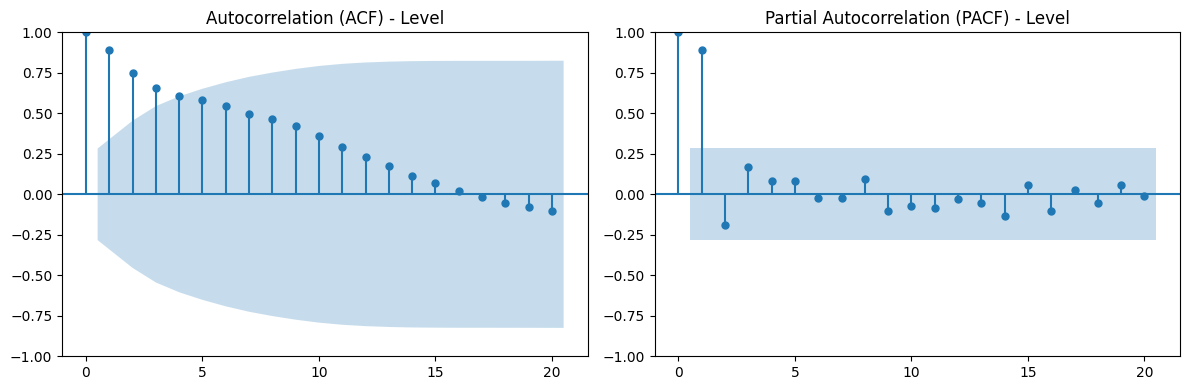

In [9]:
### Block 3d - Initial ACF and PACF Plots ###

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# AutoCorrelation (ACF) - helps determine MA(q) terms
plot_acf(total['Total_Balance'], lags=20, ax=ax[0], title="Autocorrelation (ACF) - Level")

# Partial AutoCorrelation (PACF) - helps determine AR(p) terms
plot_pacf(total['Total_Balance'], lags=20, ax=ax[1], title="Partial Autocorrelation (PACF) - Level", method='ywm')

plt.tight_layout()
plt.show()

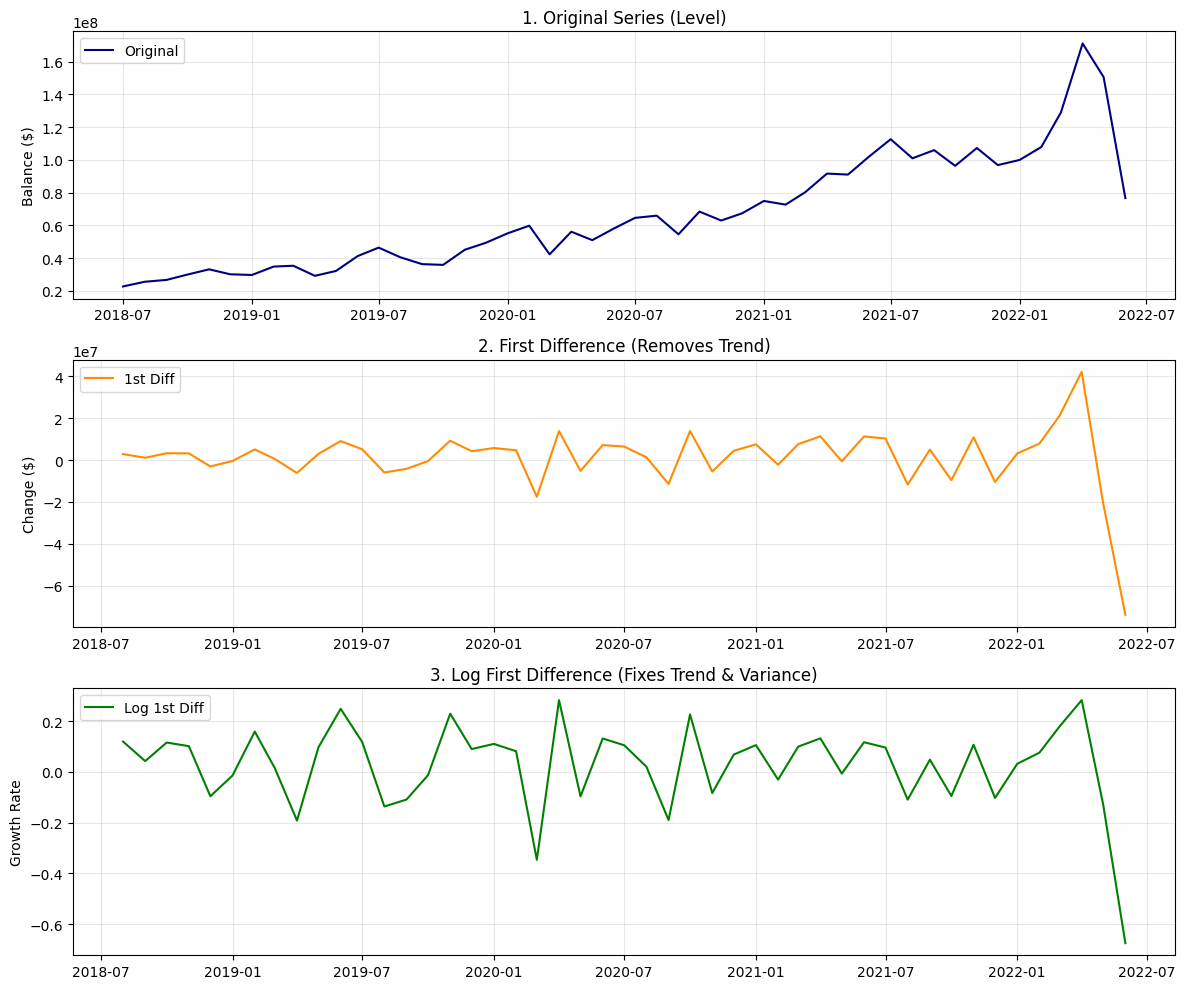

In [10]:
### Block 3e - Data Transformation ###

# Create Transformations
total['Log_Balance'] = np.log(total['Total_Balance'])
total['Diff_Balance'] = total['Total_Balance'].diff()
total['Log_Diff_Balance'] = total['Log_Balance'].diff()

# Charting
plt.figure(figsize=(12, 10))

# Plot A: Level (Original)
plt.subplot(3, 1, 1)
plt.plot(total.index, total['Total_Balance'], color='navy', label='Original')
plt.title('1. Original Series (Level)')
plt.ylabel('Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# Plot B: First Difference
plt.subplot(3, 1, 2)
plt.plot(total.index, total['Diff_Balance'], color='darkorange', label='1st Diff')
plt.title('2. First Difference (Removes Trend)')
plt.ylabel('Change ($)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# Plot C: Log First Difference (Growth Rate)
plt.subplot(3, 1, 3)
plt.plot(total.index, total['Log_Diff_Balance'], color='green', label='Log 1st Diff')
plt.title('3. Log First Difference (Fixes Trend & Variance)')
plt.ylabel('Growth Rate')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()




--- Test Results: Original Level Data ---
ADF Statistic: 0.5488 (p-value: 0.9863)
>> ADF Conclusion: Fail to reject Null (Series is likely NON-STATIONARY)
KPSS Statistic: 0.9978 (p-value: 0.0100)
>> KPSS Conclusion: Reject Null (Series is likely NON-STATIONARY)

--- Test Results: First Differenced Data ---
ADF Statistic: -6.0366 (p-value: 0.0000)
>> ADF Conclusion: Reject Null (Series is likely STATIONARY)
KPSS Statistic: 0.1370 (p-value: 0.1000)
>> KPSS Conclusion: Fail to reject Null (Series is likely STATIONARY)

--- Test Results: Log First Differenced Data ---
ADF Statistic: -5.1973 (p-value: 0.0000)
>> ADF Conclusion: Reject Null (Series is likely STATIONARY)
KPSS Statistic: 0.2817 (p-value: 0.1000)
>> KPSS Conclusion: Fail to reject Null (Series is likely STATIONARY)

--- ACF & PACF for Log First Differenced Series ---


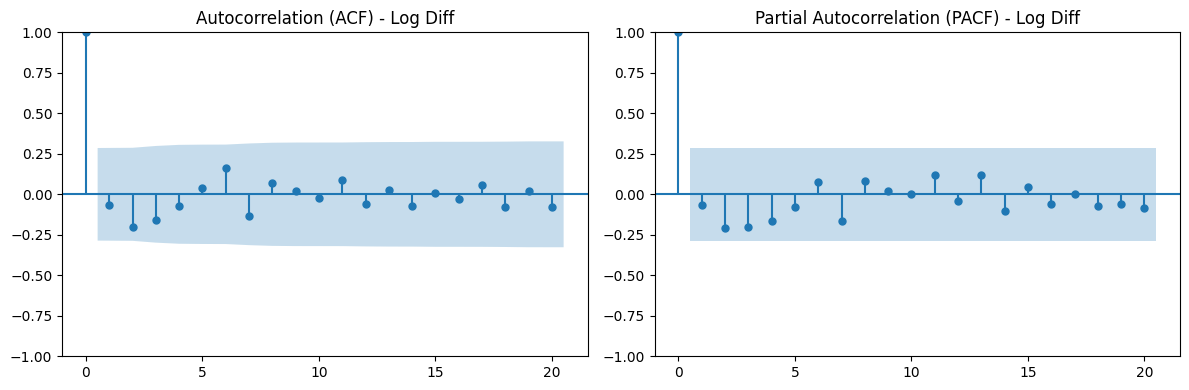

In [12]:
### Block 3f - Stationarity Tests (ADF and KPSS) ###

def run_stationarity_tests(series, name):
    print(f"\n--- Test Results: {name} ---")
    series = series.dropna()

    # ADF Test
    # Null Hypothesis: Non-Stationary
    adf_res = adfuller(series, autolag='AIC')
    print(f"ADF Statistic: {adf_res[0]:.4f} (p-value: {adf_res[1]:.4f})")
    if adf_res[1] > 0.05:
        print(">> ADF Conclusion: Fail to reject Null (Series is likely NON-STATIONARY)")
    else:
        print(">> ADF Conclusion: Reject Null (Series is likely STATIONARY)")

    # KPSS Test
    # Null Hypothesis: Stationary
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_res = kpss(series, regression='c', nlags="auto")
    print(f"KPSS Statistic: {kpss_res[0]:.4f} (p-value: {kpss_res[1]:.4f})")
    if kpss_res[1] < 0.05:
        print(">> KPSS Conclusion: Reject Null (Series is likely NON-STATIONARY)")
    else:
        print(">> KPSS Conclusion: Fail to reject Null (Series is likely STATIONARY)")

# Run on all three to compare
run_stationarity_tests(total['Total_Balance'], "Original Level Data")
run_stationarity_tests(total['Diff_Balance'], "First Differenced Data")
run_stationarity_tests(total['Log_Diff_Balance'], "Log First Differenced Data")

# ACF and PACF Plots (for Log First Difference)
print("\n--- ACF & PACF for Log First Differenced Series ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Drop NaNs locally for the plots
plot_acf(total['Log_Diff_Balance'].dropna(), ax=ax1, lags=20, title='Autocorrelation (ACF) - Log Diff')
plot_pacf(total['Log_Diff_Balance'].dropna(), ax=ax2, lags=20, title='Partial Autocorrelation (PACF) - Log Diff', method='ywm')

plt.tight_layout()
plt.show()

Choosing to move forward with log difference given stationarity, mean centered around zero, and smaller variance.

# Exogenous Variables

In [13]:
### Block 4 - Exogenous Variables ###

# Load exogenous datasets
df_r = pd.read_csv('TB3MS.csv', parse_dates=['observation_date'], index_col='observation_date')
df_spx = pd.read_csv('SP500.csv', parse_dates=['observation_date'], index_col='observation_date')

# Rename and frequency
df_r.rename(columns={'TB3MS': 'RiskFreeRate'}, inplace=True)
df_spx.rename(columns={'SP500': 'SP500'}, inplace=True)
df_r = df_r.asfreq('MS')
df_spx = df_spx.asfreq('MS')

# Transformations (Stationarity)
df_spx['SP500_LogRet'] = np.log(df_spx['SP500']).diff()

# No transformation needed for df_r['RiskFreeRate'], assuming stationarity

# Merge & Extend (Crucial Step for Forecasting)
exog_hist = pd.merge(df_r, df_spx[['SP500_LogRet']], left_index=True, right_index=True, how='inner')

# STRICT ALIGNMENT: Drop rows with missing data (removes July 2018)
exog_hist.dropna(inplace=True)

# Extend for Forecast Horizon (Naive Forecast)
# Future dates: July 2022 to June 2023
future_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='MS')

# Get last known values (from June 2022)
last_r = exog_hist.iloc[-1]['RiskFreeRate']
last_sp = exog_hist.iloc[-1]['SP500_LogRet']

# Create Future DataFrame
exog_future = pd.DataFrame(index=future_dates)
exog_future['RiskFreeRate'] = last_r
exog_future['SP500_LogRet'] = 0.0 # to change forecasting assumption about equity price changes, change "0.0" to "last_sp"
# could also do exog_future['SP500_LogRet'] = exog_hist['SP500_LogRet'].mean() which would be "long-run average return" assumption
exog_future.index.name = 'observation_date'

# Combine
exog_full = pd.concat([exog_hist, exog_future])

# Define Modeling Sets
# X_train will now start in Aug 2018, matching the valid returns data
X_train = exog_full.loc[:data_end]
X_forecast = exog_full.loc[forecast_start:forecast_end]

print(f"Exogenous Data Loaded & Aligned.")
print(f"Train Shape: {X_train.shape} (Starts: {X_train.index.min().date()})")
print(f"Forecast Shape: {X_forecast.shape}")
display(X_train.head())

Exogenous Data Loaded & Aligned.
Train Shape: (47, 2) (Starts: 2018-08-01)
Forecast Shape: (12, 2)


,RiskFreeRate,SP500_LogRet
observation_date,,
2018-08-01,2.03,0.022714
2018-09-01,2.13,0.015169
2018-10-01,2.25,-0.040815
2018-11-01,2.33,-0.022594
2018-12-01,2.37,-0.058960


In [14]:
### Block 5 - Data Preparation for Modeling & Alignment ###

# Define Target Variable (y)
# Filter 'y' to match the index of 'X_train'
# This ensures alignment with the stationary exogenous variables
y_train = total['Log_Diff_Balance'].loc[X_train.index]

# Final validation
if len(y_train) != len(X_train):
    print("\nCRITICAL ERROR: Length mismatch between Target and Exogenous Train data.")
else:
    print("\nSUCCESS: Data is perfectly aligned.")
    print(f"Modeling Period: {y_train.index.min().date()} to {y_train.index.max().date()}")

# Preview aligned data
print("\n--- Aligned Modeling Data Head ---")
display(pd.concat([y_train, X_train], axis=1).head())


SUCCESS: Data is perfectly aligned.
Modeling Period: 2018-08-01 to 2022-06-01

--- Aligned Modeling Data Head ---


,Log_Diff_Balance,RiskFreeRate,SP500_LogRet
observation_date,,,
2018-08-01,0.119687,2.03,0.022714
2018-09-01,0.042623,2.13,0.015169
2018-10-01,0.115832,2.25,-0.040815
2018-11-01,0.101502,2.33,-0.022594
2018-12-01,-0.095913,2.37,-0.058960


# Model Selection & Diagnostics

In [15]:
### Block 6a - Model Selection (Manual Grid Search with Leaderboard) ###

# Define Parameter Ranges
p = range(0, 3)   # AR terms: 0,1,2
q = range(0, 3)   # MA terms: 0,1,2
d = 0             # Already differenced (Log_Diff_Balance)

P = range(0, 2)   # Seasonal AR: 0,1
Q = range(0, 2)   # Seasonal MA: 0,1
D = 0             # No seasonal differencing (stationary)
m = 12            # Monthly seasonality

pdq = list(itertools.product(p, [d], q))
seasonal_pdq = list(itertools.product(P, [D], Q, [m]))

# Storage lists
model_results = []
best_aic = np.inf
best_order = None
best_seasonal = None
best_model = None

total_tests = len(pdq) * len(seasonal_pdq)
print(f"Testing {total_tests} SARIMAX model combinations...\n")

# Grid Search Loop
for order in pdq:
    for s_order in seasonal_pdq:
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=s_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            # Save model output
            model_results.append({
                "Order": order,
                "Seasonal": s_order,
                "AIC": results.aic,
                "BIC": results.bic
            })

            # Track best model by AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = s_order
                best_model = results

        except Exception:
            continue

# Create Leaderboard Table
df_results = pd.DataFrame(model_results)
df_results = df_results.sort_values(by="AIC").reset_index(drop=True)

print("--- TOP 5 MODELS (Sorted by Lowest AIC) ---")
display(df_results.head(5))

print("\n--- BEST MODEL IDENTIFIED ---")
print(f"Best Non-Seasonal Order (p,d,q): {best_order}")
print(f"Best Seasonal Order (P,D,Q,m):  {best_seasonal}")
print(f"Best AIC: {best_aic:.3f}")

print("\n--- BEST MODEL SUMMARY TABLE ---")
print(best_model.summary())


Testing 36 SARIMAX model combinations...

--- TOP 5 MODELS (Sorted by Lowest AIC) ---


,Order,Seasonal,AIC,BIC
0,"(2, 0, 1)","(0, 0, 0, 12)",-44.777633,-33.937659
1,"(0, 0, 2)","(0, 0, 0, 12)",-42.535916,-33.614968
2,"(1, 0, 2)","(0, 0, 0, 12)",-41.670936,-30.965798
3,"(2, 0, 2)","(0, 0, 0, 12)",-41.110615,-28.621288
4,"(1, 0, 1)","(0, 0, 0, 12)",-40.748999,-31.715687



--- BEST MODEL IDENTIFIED ---
Best Non-Seasonal Order (p,d,q): (2, 0, 1)
Best Seasonal Order (P,D,Q,m):  (0, 0, 0, 12)
Best AIC: -44.778

--- BEST MODEL SUMMARY TABLE ---
                               SARIMAX Results                                
Dep. Variable:       Log_Diff_Balance   No. Observations:                   47
Model:               SARIMAX(2, 0, 1)   Log Likelihood                  28.389
Date:                Tue, 09 Dec 2025   AIC                            -44.778
Time:                        01:56:13   BIC                            -33.938
Sample:                    08-01-2018   HQIC                           -40.737
                         - 06-01-2022                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
RiskFreeRate     0.0126      0.005

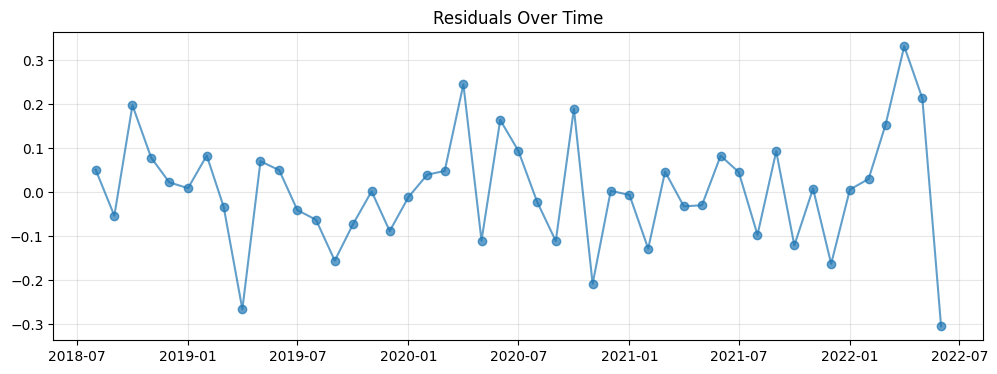

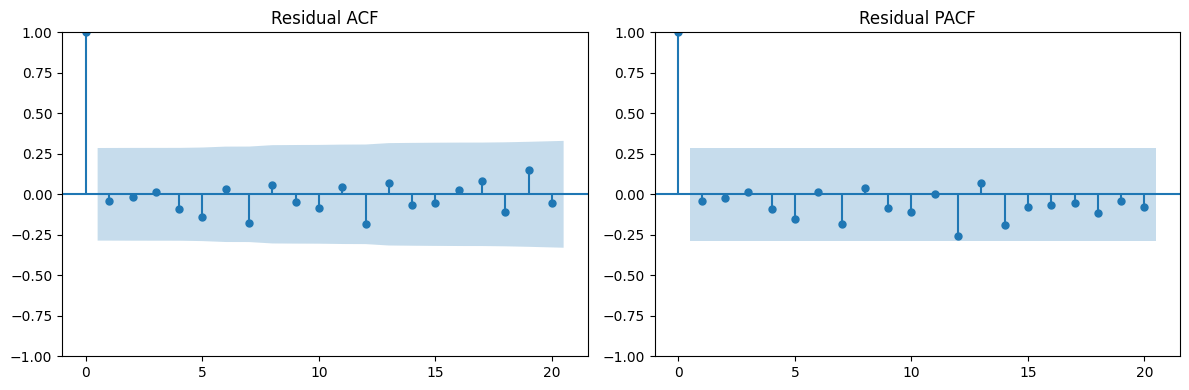


Ljung-Box Test (Lag 10):


,lb_stat,lb_pvalue
10,4.326599,0.931413



Shapiro-Wilk Normality Test:
Statistic = 0.9873, p-value = 0.8855


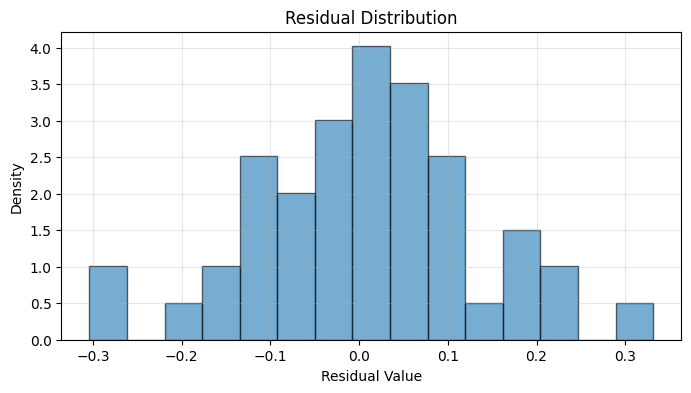

In [16]:
### Block 6b - SARIMAX Residual Diagnostics ###

resid = best_model.resid

# 1. Residual Plot
plt.figure(figsize=(12,4))
plt.plot(resid, marker='o', linestyle='-', alpha=0.7)
plt.title("Residuals Over Time")
plt.grid(True, alpha=0.3)
plt.show()

# 2. ACF & PACF of Residuals
fig, ax = plt.subplots(1,2, figsize=(12,4))

sm.graphics.tsa.plot_acf(resid, lags=20, ax=ax[0])
ax[0].set_title("Residual ACF")

sm.graphics.tsa.plot_pacf(resid, lags=20, ax=ax[1], method='ywm')
ax[1].set_title("Residual PACF")

plt.tight_layout()
plt.show()

# 3. Ljung-Box Test (Autocorrelation)
ljung = sm.stats.acorr_ljungbox(resid, lags=[10], return_df=True)
print("\nLjung-Box Test (Lag 10):")
display(ljung)

# 4. Shapiro-Wilk Test (Normality)
sw_test = shapiro(resid)
print("\nShapiro-Wilk Normality Test:")
print(f"Statistic = {sw_test.statistic:.4f}, p-value = {sw_test.pvalue:.4f}")

# 5. Histogram
plt.figure(figsize=(8,4))
plt.hist(resid, bins=15, density=True, alpha=0.6, edgecolor='black')
plt.title("Residual Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()



Train Period: 2018-08-01 to 2021-08-01 (37 obs)
Test Period:  2021-09-01  to 2022-06-01  (10 obs)

Backtest RMSE (Dollars): $31,706,243.70


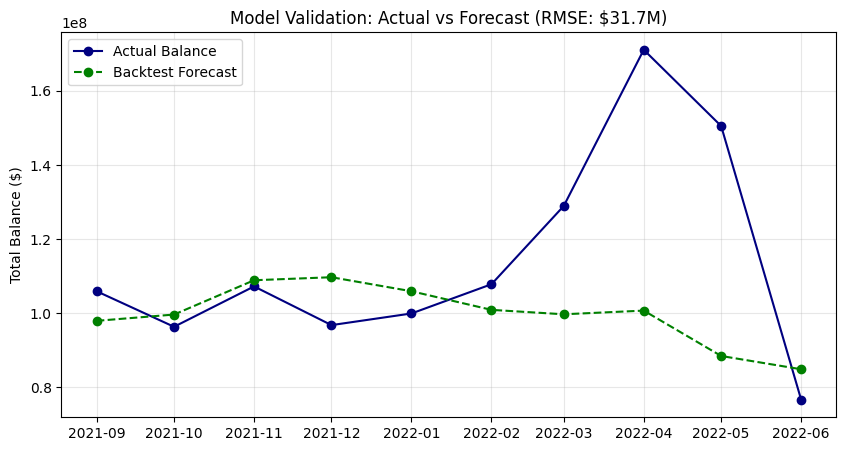

In [17]:
### Block 6c - Backtesting & RMSE on Log-Diff Series ###

# Define 80/20 Split
n_obs = len(y_train)
split_idx = int(n_obs * 0.8)

# Split Target (y)
y_bt_train = y_train.iloc[:split_idx]
y_bt_test  = y_train.iloc[split_idx:]

# Split Exogenous (X)
X_bt_train = X_train.iloc[:split_idx]
X_bt_test  = X_train.iloc[split_idx:]

print(f"Train Period: {y_bt_train.index.min().date()} to {y_bt_train.index.max().date()} ({len(y_bt_train)} obs)")
print(f"Test Period:  {y_bt_test.index.min().date()}  to {y_bt_test.index.max().date()}  ({len(y_bt_test)} obs)")

# Fit Model on Training Subset
bt_model = SARIMAX(y_bt_train,
                   exog=X_bt_train,
                   order=best_order,
                   seasonal_order=best_seasonal,
                   enforce_stationarity=False,
                   enforce_invertibility=False)
bt_results = bt_model.fit(disp=False)

# Forecast Log-Diffs
bt_pred_obj = bt_results.get_forecast(steps=len(y_bt_test), exog=X_bt_test)
forecast_log_diff_bt = bt_pred_obj.predicted_mean

# RECONSTRUCT TO DOLLARS
# the last actual log level from the training period to anchor the forecast
last_train_log_level = total.loc[y_bt_train.index[-1], 'Log_Balance']

# Cumulative sum of predicted growth
forecast_log_level_bt = last_train_log_level + forecast_log_diff_bt.cumsum()

# Convert to Dollars
forecast_dollars_bt = np.exp(forecast_log_level_bt)

# Get Actual Dollars for comparison
actual_dollars_bt = total.loc[y_bt_test.index, 'Total_Balance']

# Compute RMSE in Dollars
mse_dollars = mean_squared_error(actual_dollars_bt, forecast_dollars_bt)
rmse_dollars = np.sqrt(mse_dollars)

print(f"\nBacktest RMSE (Dollars): ${rmse_dollars:,.2f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(actual_dollars_bt.index, actual_dollars_bt, label="Actual Balance", color='navy', marker='o')
plt.plot(forecast_dollars_bt.index, forecast_dollars_bt, label="Backtest Forecast", color='green', linestyle='--', marker='o')
plt.title(f"Model Validation: Actual vs Forecast (RMSE: ${rmse_dollars/1e6:.1f}M)")
plt.ylabel("Total Balance ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Fitting SARIMAX Model & Forecasting

Refitting SARIMAX(2, 0, 1)x(0, 0, 0, 12) on full training set...

Final Model Coefficients:
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
RiskFreeRate     0.0126      0.005      2.649      0.008       0.003       0.022
SP500_LogRet     1.8683      0.280      6.662      0.000       1.319       2.418
ar.L1            0.7859      0.219      3.589      0.000       0.357       1.215
ar.L2           -0.4626      0.196     -2.366      0.018      -0.846      -0.079
ma.L1           -1.0000    340.939     -0.003      0.998    -669.227     667.227
sigma2           0.0152      5.191      0.003      0.998     -10.159      10.190

Generating forecast from 2022-07-01 to 2023-06-01...

--- First 5 rows of Log-Diff Forecast ---


,LogDiff_Forecast,Lower_CI,Upper_CI
2022-07-01,-0.183495,-0.427958,0.060967
2022-08-01,0.149862,-0.099051,0.398776
2022-09-01,0.215373,-0.075282,0.506029
2022-10-01,0.112657,-0.193495,0.418809
2022-11-01,0.001633,-0.304578,0.307844


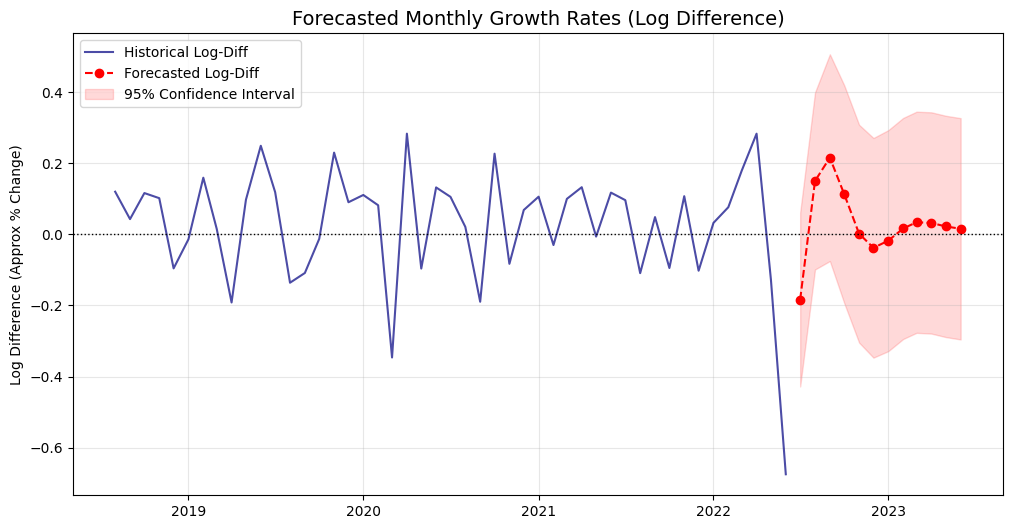

In [18]:
### Block 7 — Final SARIMAX Model Fit & Forecasting (Log-Diff Only) ###

# Fit Final Model
# Use the optimal parameters found in Block 6
print(f"Refitting SARIMAX{best_order}x{best_seasonal} on full training set...")

final_model = SARIMAX(y_train,
                      exog=X_train,
                      order=best_order,
                      seasonal_order=best_seasonal,
                      enforce_stationarity=False,
                      enforce_invertibility=False)

results_final = final_model.fit(disp=False)

# Print specific coefficient table to verify significance again
print("\nFinal Model Coefficients:")
print(results_final.summary().tables[1])

# Generate Forecast (Log Growth Rates)
print(f"\nGenerating forecast from {forecast_start} to {forecast_end}...")

# Use the Future Exogenous variables (X_forecast) created in Block 4
pred_obj = results_final.get_forecast(steps=12, exog=X_forecast)

# Extract predicted mean and confidence intervals
forecast_log_diff = pred_obj.predicted_mean
conf_int_log_diff = pred_obj.conf_int()

# Organize into a clean DataFrame
df_forecast_log = pd.DataFrame({
    'LogDiff_Forecast': forecast_log_diff,
    'Lower_CI': conf_int_log_diff.iloc[:, 0],
    'Upper_CI': conf_int_log_diff.iloc[:, 1]
})

print("\n--- First 5 rows of Log-Diff Forecast ---")
display(df_forecast_log.head())

# Plot Forecast (Log Scale)
# Inspect the "Stability" of the forecast before converting to dollars on plot
plt.figure(figsize=(12, 6))

# Plot history
plt.plot(y_train.index, y_train, label='Historical Log-Diff', color='navy', alpha=0.7)

# Plot forecast
plt.plot(df_forecast_log.index, df_forecast_log['LogDiff_Forecast'],
         label='Forecasted Log-Diff', color='red', linestyle='--', marker='o')

# Plot confidence Interval
plt.fill_between(df_forecast_log.index,
                 df_forecast_log['Lower_CI'],
                 df_forecast_log['Upper_CI'],
                 color='red', alpha=0.15, label='95% Confidence Interval')

plt.title('Forecasted Monthly Growth Rates (Log Difference)', fontsize=14)
plt.axhline(0, color='black', linewidth=1, linestyle=':') # Zero line for reference
plt.ylabel('Log Difference (Approx % Change)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


# Reconstructed Forecasted Levels

Anchor (June 2022 Log Balance): 18.1548

--- First 5 rows of Level Forecast ($) ---


,Forecast_Balance,Lower_Balance,Upper_Balance
2022-07-01,6.380447e+07,4.996667e+07,8.147452e+07
2022-08-01,7.412000e+07,5.228949e+07,1.050646e+08
2022-09-01,9.193287e+07,5.837906e+07,1.447720e+08
2022-10-01,1.028956e+08,5.950421e+07,1.779288e+08
2022-11-01,1.030638e+08,5.503042e+07,1.930233e+08


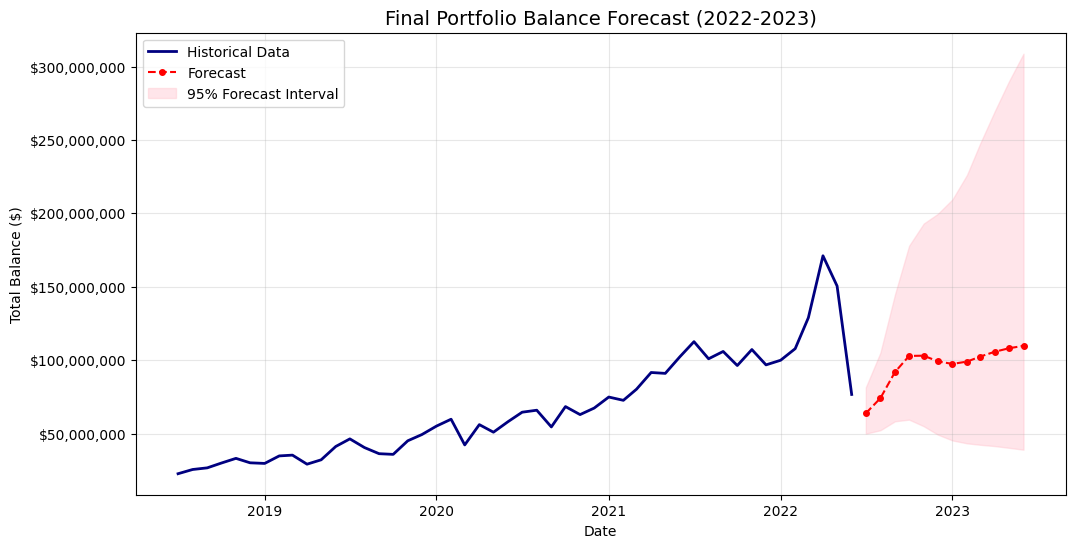

In [19]:
### Block 8 — Reconstruct Portfolio Balance Levels from Log-Diff Forecasts ###

# 1. Get last historical log level
# Use the end date of the training data to anchor the forecast
last_log_level = total.loc[data_end, "Log_Balance"]
print(f"Anchor (June 2022 Log Balance): {last_log_level:.4f}")

# 2. Extract Forecasted Diffs & Standard Errors
# pred_obj was created in Block 7
logdiff_hat = df_forecast_log["LogDiff_Forecast"]
se_logdiff = pred_obj.se_mean  # Get standard error for each step

# 3. Calculate Cumulative Statistics in Log Space
# Cumulative Sum of the mean (Point Forecast)
cum_mean = logdiff_hat.cumsum()

# Cumulative Variance of the sum (Approximate error accumulation)
# Var(Sum) = Sum(Var) assuming independence
cum_var = (se_logdiff ** 2).cumsum()
cum_se = np.sqrt(cum_var)

# 4. Construct Intervals in Log Space
log_level_forecast = last_log_level + cum_mean
log_level_lower = log_level_forecast - 1.96 * cum_se
log_level_upper = log_level_forecast + 1.96 * cum_se

# 5. Transform to Dollars (Exponential)
level_forecast = np.exp(log_level_forecast)
level_lower = np.exp(log_level_lower)
level_upper = np.exp(log_level_upper)

# 6. Create Final DataFrame
df_forecast_level = pd.DataFrame({
    "Forecast_Balance": level_forecast,
    "Lower_Balance": level_lower,
    "Upper_Balance": level_upper
})

print("\n--- First 5 rows of Level Forecast ($) ---")
display(df_forecast_level.head())

# 7. Plot History + Forecast
plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(total.index, total["Total_Balance"], label="Historical Data", color="navy", linewidth=2)

# Forecast Data
plt.plot(df_forecast_level.index, df_forecast_level["Forecast_Balance"],
         label="Forecast", color="red", linestyle="--", marker="o", markersize=4)

# Confidence Interval
plt.fill_between(df_forecast_level.index,
                 df_forecast_level["Lower_Balance"],
                 df_forecast_level["Upper_Balance"],
                 color="pink", alpha=0.4, label="95% Forecast Interval")

plt.title("Final Portfolio Balance Forecast (2022-2023)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Balance ($)")

# Format Y-Axis to Billions/Millions
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

# Exporting to CSV

1. Saved 'portfolio_forecast.csv' (Forecast_Date, Total_Balance)
2. Saved 'exogenous_variables.csv' (Date, RiskFreeRate, SP500_LogRet)

Final Submission Head:


,Forecast_Date,Total_Balance
0,2022-07-01,6.380447e+07
1,2022-08-01,7.412000e+07
2,2022-09-01,9.193287e+07
3,2022-10-01,1.028956e+08
4,2022-11-01,1.030638e+08


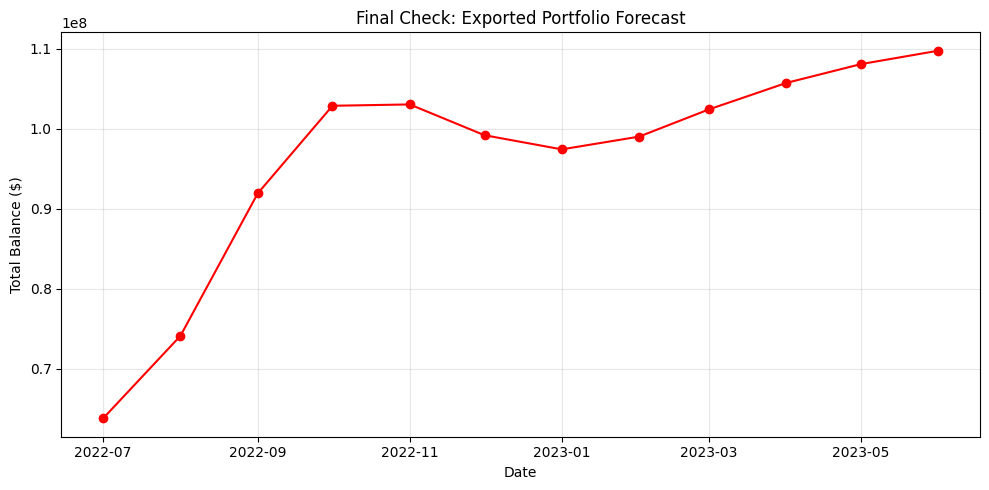

In [20]:
### Block 9 — Export Forecast & Exogenous Regressors to CSV ###

# Portfolio forecast CSV (2 columns: date + total balance)
# df_forecast_level index should be the forecast dates (2022-07-01 to 2023-06-01)
df_tmp = df_forecast_level.copy()
df_tmp.index.name = "Date"

submission_df = df_tmp[["Forecast_Balance"]].reset_index()
submission_df.rename(
    columns={"Date": "Forecast_Date", "Forecast_Balance": "Total_Balance"},
    inplace=True
)

# Save forecast file
submission_df.to_csv("portfolio_forecast.csv", index=False)

print("1. Saved 'portfolio_forecast.csv' (Forecast_Date, Total_Balance)")

# Exogenous variables CSV (history + forecast)
# exog_full already contains historical + future exogenous paths
exog_export = exog_full.copy()
exog_export.index.name = "Date"      # date as first column
exog_export.to_csv("exogenous_variables.csv")

print("2. Saved 'exogenous_variables.csv' (Date, RiskFreeRate, SP500_LogRet)")

# Quick check of the exported forecast
print("\nFinal Submission Head:")
display(submission_df.head())

plt.figure(figsize=(10, 5))
plt.plot(submission_df["Forecast_Date"], submission_df["Total_Balance"],
         color="red", marker="o")
plt.title("Final Check: Exported Portfolio Forecast")
plt.xlabel("Date")
plt.ylabel("Total Balance ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Testing different forecasting assumptions

This chart may be useful in explaining how different forecasting assumptions on the exogenous variables affect the overall total balance forecast. We assume 0% equity returns over the forecast period in the model. This tests different scenarios, including extending the -3.6% monthly return from June 2022--the last date of historical data--and one scenario assuming a 1% return per month in the S&P 500.

Anchor (June 2022 Log Balance): 18.1548
Bear Case Assumption: -0.0356 monthly log return


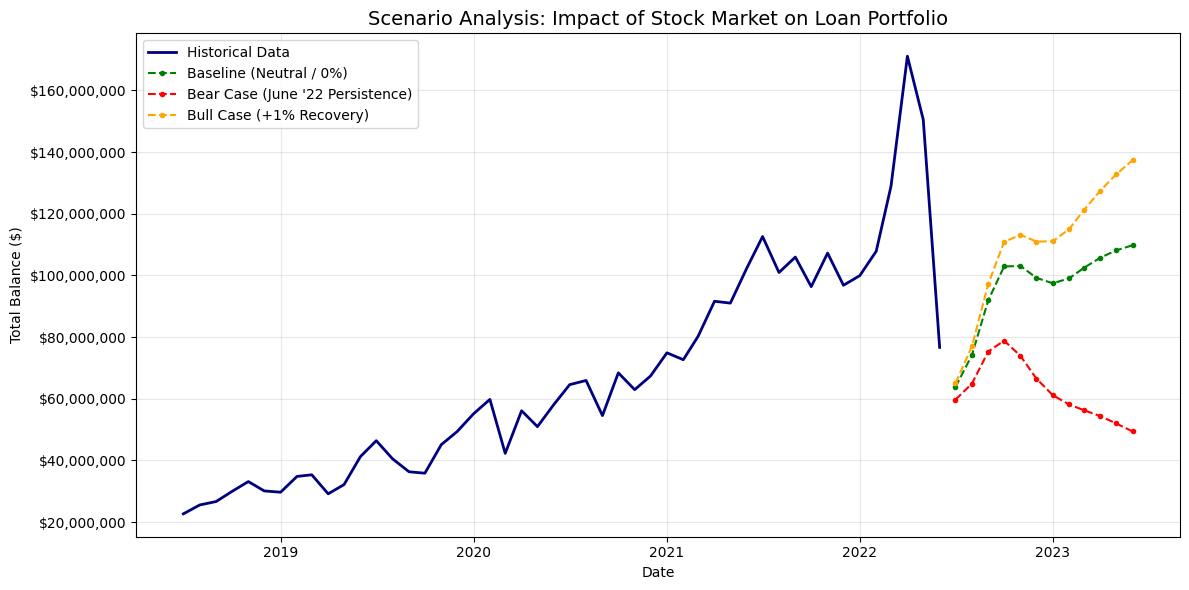

In [21]:
### Block 10 — Scenario Analysis for Exogenous Variables ###

import matplotlib.ticker as mtick

# Safety check: ensure final model exists
try:
    results_final
except NameError:
    print("results_final not found – refitting model.")
    results_final = SARIMAX(
        y_train,
        exog=X_train,
        order=best_order,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

# 1. Anchor log level
last_log_level = total.loc[data_end, "Log_Balance"]
print(f"Anchor (June 2022 Log Balance): {last_log_level:.4f}")

# 2. Define Scenarios
# A. Baseline (Official Forecast)
# This uses the X_forecast created in Block 4 (0.0% S&P growth)
baseline_X = X_forecast.copy()

# B. Bear Case (Stress Test)
# Assume the negative returns of June 2022 persist for the whole year
# Grab the last historical value from exog_hist
bear_market_X = X_forecast.copy()
last_observed_sp_return = exog_full.loc[data_end, 'SP500_LogRet']
bear_market_X["SP500_LogRet"] = last_observed_sp_return # Approx -3.6%
print(f"Bear Case Assumption: {last_observed_sp_return:.4f} monthly log return")

# C. Bull Case (Recovery)
# Assume a +1% monthly return
bull_market_X = X_forecast.copy()
bull_market_X["SP500_LogRet"] = 0.01

scenarios = {
    "Baseline (Neutral / 0%)": baseline_X,
    "Bear Case (June '22 Persistence)": bear_market_X,
    "Bull Case (+1% Recovery)": bull_market_X
}

# 3. Helper Function
def scenario_level_forecast(Xf, model, last_log_level):
    pred = model.get_forecast(steps=len(Xf), exog=Xf)
    logdiff_hat = pred.predicted_mean
    se_logdiff = pred.se_mean

    # Cumulative stats in log space
    cum_mean = logdiff_hat.cumsum()
    log_level_fc = last_log_level + cum_mean

    return np.exp(log_level_fc)

# 4. Generate Forecasts
scenario_levels = {}
for name, Xf in scenarios.items():
    scenario_levels[name] = scenario_level_forecast(Xf, results_final, last_log_level)

# 5. Plot Comparison
plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(
    total.index,
    total["Total_Balance"],
    label="Historical Data",
    color="navy",
    linewidth=2
)

# Scenario Forecasts
colors = {
    "Baseline (Neutral / 0%)": "green",        # Official forecast
    "Bear Case (June '22 Persistence)": "red", # The downward trend
    "Bull Case (+1% Recovery)": "orange"       # The optimistic trend
}

for name, series in scenario_levels.items():
    plt.plot(
        series.index,
        series.values,
        label=name,
        linestyle="--",
        marker="o",
        markersize=3,
        color=colors.get(name, "gray")
    )

plt.title("Scenario Analysis: Impact of Stock Market on Loan Portfolio", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Balance ($)")

# Format Y-axis to Dollars
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()